# Read data

In [1]:
from __future__ import absolute_import, division, print_function, unicode_literals
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow import keras
from tensorflow.keras.models import Sequential
import os

import string
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import PIL
import random
import time
from pathlib import Path

from tqdm import tqdm

import re
from IPython import display

gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        # Restrict TensorFlow to only use the first GPU
        tf.config.experimental.set_visible_devices(gpus[0], 'GPU')

        # Currently, memory growth needs to be the same across GPUs
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        logical_gpus = tf.config.experimental.list_logical_devices('GPU')
        print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPUs")
    except RuntimeError as e:
        # Memory growth must be set before GPUs have been initialized
        print(e)

BATCH_SIZE = 64

2026-03-12 09:41:44.272779: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-12 09:41:44.302766: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773308504.323904    8111 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773308504.329487    8111 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-12 09:41:44.362664: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

1 Physical GPUs, 1 Logical GPUs


I0000 00:00:1773308506.959332    8111 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9513 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4070 SUPER, pci bus id: 0000:01:00.0, compute capability: 8.9


In [2]:
x_train = np.load('./dataset/x_train_cifar10_unlearn.npy')
y_train = np.load('./dataset/y_train_cifar10.npy')
x_val = np.load('./dataset/x_val_cifar10.npy')
y_val = np.load('./dataset/y_val_cifar10.npy')


#Preprocess image

這邊主要嘗試對照片進行不同的前處理，都是在tfdata中過一個map函數，期望可以減輕或消除中毒資料中的雜訊問題：
1. 壓縮色彩深度 + (填充色彩深度) fn: img_comp1  
   原本RGB三色的深度都是0到255，設定一個壓縮因子N，令0=0到N, 1=N到2N ,...  
   另外也有嘗試順帶添加小於N的隨機雜訊試圖稀釋中毒訊號。
2. 高通訊號(縮小色階)fn: img_comp2  
   設定一個filter的值N，低於或高於N的數值令為0或255。
3. 隨機添加不同隨機雜訊 fn: img_noise  
   隨機放入不同常態的雜訊，效果不是太好。
4. (低通) + JPEG壓縮-解壓縮 fn: gray_comp1  
   JPEG壓縮可能會將雜訊壓縮掉，另外我自己開PS看了一下中毒水母與原始水母的色彩分配，  
   覺得轉成黑白後，兩者照片色彩分配在某個值後的分配比較相似(training 79到255, val 63到255)，    
   所以這先嘗試training data跟val data都先砍到相同的起始點再做jpeg壓縮。
5. 多次JPEG壓縮-解壓縮 fn: gray_comp2  
   這邊嘗試多次進行jpeg壓縮與調整色彩的對比度，看能不能將圖片壓縮到剩下比較重要的資訊。
   
在這些嘗試中gray_comp1的表現比較好，imagenet預測正確率0.88,CIFAR-10預測正確率0.55

In [3]:
import tensorflow_probability as tfp

def sample_beta_distribution(size, concentration_0=0.2, concentration_1=0.2):
    # 從 Beta 分配中抽樣 lambda
    gamma_1_sample = tf.random.gamma(shape=[size], alpha=concentration_1)
    gamma_2_sample = tf.random.gamma(shape=[size], alpha=concentration_0)
    return gamma_1_sample / (gamma_1_sample + gamma_2_sample)

def mixup(ds_one, ds_two, alpha=0.2):
    # 解包兩組資料 (images, labels)
    images_one, labels_one = ds_one
    images_two, labels_two = ds_two

    # 獲取 batch size
    batch_size = tf.shape(images_one)[0]

    # 抽樣 lambda 權重 (維度擴充以符合圖片的 [Batch, W, H, C])
    l = sample_beta_distribution(batch_size, alpha, alpha)
    x_l = tf.reshape(l, (batch_size, 1, 1, 1))
    y_l = tf.reshape(l, (batch_size, 1))

    # 混合圖片與標籤
    images = images_one * x_l + images_two * (1 - x_l)
    labels = labels_one * y_l + labels_two * (1 - y_l)

    return (images, labels)

In [4]:
#先將數值放大到0~255，整除N再乘N，填充微量的常態雜訊
def img_comp1(img,label):
  ran1 = tf.random.uniform(shape=[32,32,3], minval=1, maxval=50)//1
  ran2 = tf.random.normal(shape=[32,32,3], mean=25, stddev=7)/255
  RGB_Max = tf.constant(255, dtype=tf.float32, shape=[32, 32, 3])
  
  img = tf.multiply(img,RGB_Max)
  img = tf.math.floordiv(img, ran1)
  img = tf.multiply(img, ran1)
  img = tf.divide(img,RGB_Max)

  img = tf.add(img, ran2)

  img = tf.math.minimum(img,1)
  img = tf.math.maximum(img,0)

  img = tf.image.adjust_contrast(img, 0.5)

#  img = tf.image.resize(img, [20,16])
#  img = tf.image.resize(img, [32,32])
  

  return (img,label) 

In [5]:
#加一點常態雜訊、保留100~255的數值
def img_comp2(img,label):
  RGB_Max = tf.constant(255, dtype=tf.float32, shape=[32, 32, 3])
  ran1 = tf.random.normal(shape=[32,32,3], mean=1, stddev=5)


  img = tf.multiply(img,RGB_Max)//1
  img = tf.add(img, ran1)

  RGB_Cut = tf.math.greater_equal(img, 100)
  RGB_Cut = tf.cast(RGB_Cut, tf.float32)
  img = tf.multiply(img, RGB_Cut)

  img = tf.divide(img,RGB_Max)
  img = tf.math.minimum(img,1)
  img = tf.math.maximum(img,0)


  return (img,label) 

In [6]:
#嘗試添加各種不同常態雜訊
def img_noise(img,label):
  ran1 = tf.random.normal(shape=[32,32,3], mean=0.01, stddev=0.005)
  ran = tf.random.normal(shape=[32,32,3], mean=ran1, stddev=0.005)
  img = tf.add(img, ran)
  ran1 = tf.random.normal(shape=[32,32,3], mean=0.001, stddev=0.0005)
  ran = tf.random.normal(shape=[32,32,3], mean=ran1, stddev=0.005)
  img = tf.add(img, ran)
  ran1 = tf.random.normal(shape=[32,32,3], mean=0.0001, stddev=0.00005)
  ran = tf.random.normal(shape=[32,32,3], mean=ran1, stddev=0.005)
  img = tf.add(img, ran)
  return (img,label) 

In [7]:
#對training data砍掉0~79的數值、做JPEG的大幅壓縮
def gray_comp1_train(img,label):
  RGB_Max = tf.constant(255, dtype=tf.float32, shape=[32, 32, 3])
  
  img = tf.multiply(img,RGB_Max)//1

  RGB_Cut = tf.math.greater_equal(img, 79)
  RGB_Cut = tf.cast(RGB_Cut, tf.float32)
  img = tf.multiply(img, RGB_Cut)
  img = tf.math.subtract(img, tf.constant(16, dtype=tf.float32, shape=[32, 32, 3]))
  img = tf.math.maximum(img,0)

  img = tf.cast(img, tf.uint8)
  img_jpg = tf.io.encode_jpeg(img, quality=20)   
  img = tf.io.decode_jpeg(img_jpg, channels=0)
  img = tf.cast(img, tf.float32)

  img = tf.divide(img,RGB_Max)
  

  return (img,label) 

In [8]:
#對val data砍掉0~63的數值、做JPEG的大幅壓縮
def gray_comp1_val(img,label):
  RGB_Max = tf.constant(255, dtype=tf.float32, shape=[32, 32, 3])
  
  img = tf.multiply(img,RGB_Max)//1
  
  RGB_Cut = tf.math.greater_equal(img, 63)
  RGB_Cut = tf.cast(RGB_Cut, tf.float32)
  img = tf.multiply(img, RGB_Cut)

  img = tf.cast(img, tf.uint8)
  img_jpg = tf.io.encode_jpeg(img, quality=20)   
  img = tf.io.decode_jpeg(img_jpg, channels=0)
  img = tf.cast(img, tf.float32)

  img = tf.divide(img,RGB_Max)
  

  return (img,label)

In [9]:
#對training data做大量不同程度的JPEG壓縮
def gray_comp2_train(img,label):
  RGB_Max = tf.constant(255, dtype=tf.float32, shape=[32, 32, 3])
  
  img = tf.multiply(img,RGB_Max)//1

  img = tf.cast(img, tf.uint8)
  img = tf.image.adjust_contrast(img, 0.8)
  img_jpg = tf.io.encode_jpeg(img, quality=90)   
  img = tf.io.decode_jpeg(img_jpg, channels=0)
  img = tf.image.adjust_contrast(img, 2)
  img_jpg = tf.io.encode_jpeg(img, quality=75)   
  img = tf.io.decode_jpeg(img_jpg, channels=0)
  img = tf.image.adjust_contrast(img, 0.6)
  img_jpg = tf.io.encode_jpeg(img, quality=80)   
  img = tf.io.decode_jpeg(img_jpg, channels=0)
  img = tf.image.adjust_contrast(img, 1.3)
  img_jpg = tf.io.encode_jpeg(img, quality=70)   
  img = tf.io.decode_jpeg(img_jpg, channels=1)      
  img = tf.cast(img, tf.float32)

  img = tf.divide(img,RGB_Max)
  

  return (img,label) 

In [10]:
#對val data做一次簡單的JPEG壓縮
def gray_comp2_val(img,label):
  RGB_Max = tf.constant(255, dtype=tf.float32, shape=[32, 32, 3])
  
  img = tf.multiply(img,RGB_Max)//1
  
  img = tf.cast(img, tf.uint8)
  img_jpg = tf.io.encode_jpeg(img, quality=100)   
  img = tf.io.decode_jpeg(img_jpg, channels=1)
  img = tf.cast(img, tf.float32)

  img = tf.divide(img,RGB_Max)
  

  return (img,label)

In [ ]:
#建立並前處理基礎 Dataset
train_dataset = tf.data.Dataset.from_tensor_slices((x_train, y_train))
train_dataset = train_dataset.map(gray_comp1_train, num_parallel_calls=tf.data.AUTOTUNE)

# 建立第二個打亂的 Dataset
train_dataset_two = train_dataset.shuffle(buffer_size=1024)

#將兩個 Dataset 打包成 Batch
batched_ds_one = train_dataset.batch(BATCH_SIZE, drop_remainder=True)
batched_ds_two = train_dataset_two.batch(BATCH_SIZE, drop_remainder=True)

#將兩個 Batch Dataset zip 起來，並套用 mixup
mixup_dataset = tf.data.Dataset.zip((batched_ds_one, batched_ds_two))
batched_dataset = mixup_dataset.map(
    lambda ds_one, ds_two: mixup(ds_one, ds_two, alpha=0.2), 
    num_parallel_calls=tf.data.AUTOTUNE
)

# 驗證集照舊
val_dataset = tf.data.Dataset.from_tensor_slices((x_val, y_val))
val_dataset = val_dataset.map(gray_comp1_val, num_parallel_calls=tf.data.AUTOTUNE)
batched_val_dataset = val_dataset.batch(BATCH_SIZE, drop_remainder=True)

In [12]:
"""train_dataset = tf.data.Dataset.from_tensor_slices((x_train, y_train))
train_dataset = train_dataset.map(gray_comp1_train, num_parallel_calls=tf.data.experimental.AUTOTUNE)
batched_dataset = train_dataset.batch(BATCH_SIZE, drop_remainder=True)

val_dataset = tf.data.Dataset.from_tensor_slices((x_val, y_val))
val_dataset = val_dataset.map(gray_comp1_val, num_parallel_calls=tf.data.experimental.AUTOTUNE)
batched_val_dataset = val_dataset.batch(BATCH_SIZE, drop_remainder=True)"""

'train_dataset = tf.data.Dataset.from_tensor_slices((x_train, y_train))\ntrain_dataset = train_dataset.map(gray_comp1_train, num_parallel_calls=tf.data.experimental.AUTOTUNE)\nbatched_dataset = train_dataset.batch(BATCH_SIZE, drop_remainder=True)\n\nval_dataset = tf.data.Dataset.from_tensor_slices((x_val, y_val))\nval_dataset = val_dataset.map(gray_comp1_val, num_parallel_calls=tf.data.experimental.AUTOTUNE)\nbatched_val_dataset = val_dataset.batch(BATCH_SIZE, drop_remainder=True)'

2026-03-12 09:41:55.755732: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


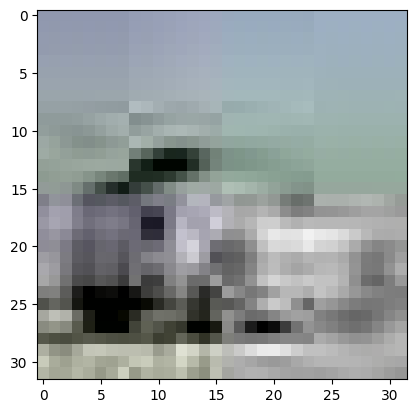

In [13]:
for data in batched_dataset.take(2):
    plt.imshow(data[0][3],cmap='gray')

2026-03-12 09:41:55.908836: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


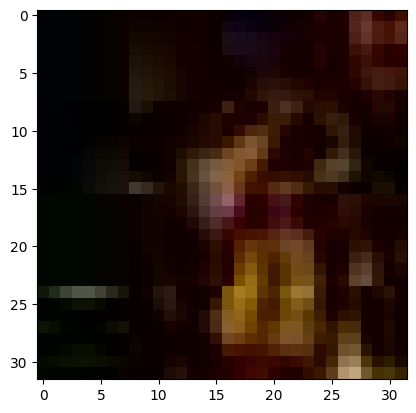

In [14]:
for data in batched_val_dataset.take(2):
    plt.imshow(data[0][3],cmap='gray')

#Model

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

EPOCHS = 50
steps_per_epoch = len(batched_dataset) 
total_steps = EPOCHS * steps_per_epoch

lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=0.0005, 
    decay_steps=total_steps,
    alpha=0.01
)

# 載入帶有 ImageNet 權重的 ResNet50V2 ---
base_model = tf.keras.applications.ResNet50V2(
    include_top=False, 
    weights='imagenet', 
    input_shape=(32, 32, 3)
)

model = models.Sequential([
    keras.Input(shape=(32, 32, 3)),
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1), 
    
    layers.Rescaling(scale=2.0, offset=-1.0),
    
    base_model,
    
    layers.GlobalAveragePooling2D(),
    layers.Dense(10) 
])

loss_fn = tf.keras.losses.CategoricalCrossentropy(from_logits=True)
optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)

model.compile(optimizer=optimizer, loss=loss_fn, metrics=['acc'])

In [ ]:
callback_es = tf.keras.callbacks.EarlyStopping(
    patience=15,
    monitor='val_acc', 
    restore_best_weights=True
)

history = model.fit(
    x=batched_dataset, 
    validation_data=batched_val_dataset, 
    epochs=EPOCHS,
    verbose=1,
    callbacks=[callback_es]
)

Epoch 1/50


I0000 00:00:1773308534.092937    8196 cuda_dnn.cc:529] Loaded cuDNN version 90300


625/625 ━━━━━━━━━━━━━━━━━━━━ 131s 166ms/step - acc: 0.2307 - loss: 2.1641 - val_acc: 0.2484 - val_loss: 84.4927
Epoch 2/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 102s 164ms/step - acc: 0.3606 - loss: 1.8798 - val_acc: 0.3849 - val_loss: 2.1040
Epoch 3/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 94s 151ms/step - acc: 0.4164 - loss: 1.7981 - val_acc: 0.1195 - val_loss: 3.5457
Epoch 4/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 81s 129ms/step - acc: 0.3894 - loss: 1.8607 - val_acc: 0.4650 - val_loss: 1.7454
Epoch 5/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 62s 98ms/step - acc: 0.4873 - loss: 1.6103 - val_acc: 0.4852 - val_loss: 1.5498
Epoch 6/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 59s 94ms/step - acc: 0.5257 - loss: 1.5094 - val_acc: 0.4688 - val_loss: 2.0528
Epoch 7/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 62s 99ms/step - acc: 0.5428 - loss: 1.4892 - val_acc: 0.5060 - val_loss: 1.4866
Epoch 8/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 65s 104ms/step - acc: 0.5750 - loss: 1.4094 - val_acc: 0.4765 - val_loss: 1.8741
Epoch 9/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 60s

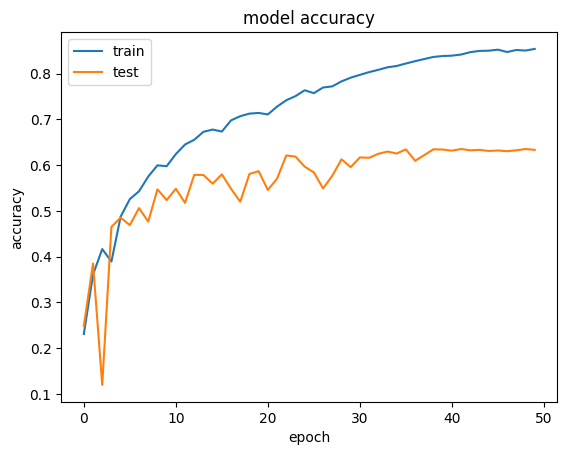

In [23]:
plt.plot(history.history['acc'])
plt.plot(history.history['val_acc'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

#predict

In [24]:
import tensorflow as tf

@tf.function
def gray_comp_test(img):
    RGB_Max = tf.constant(255, dtype=tf.float32, shape=[32, 32, 3])
    img = tf.multiply(img, RGB_Max) // 1
  
    RGB_Cut = tf.math.greater_equal(img, 63)
    RGB_Cut = tf.cast(RGB_Cut, tf.float32)
    img = tf.multiply(img, RGB_Cut)

    img = tf.cast(img, tf.uint8)
    img_jpg = tf.io.encode_jpeg(img, quality=20) 
    
    img = tf.io.decode_jpeg(img_jpg, channels=0) 
    img = tf.cast(img, tf.float32)
    img = tf.divide(img, RGB_Max) 
  
    return img

In [25]:
x_test = np.load('./dataset/x_test_cifar10.npy')
test_dataset = tf.data.Dataset.from_tensor_slices(x_test)
test_dataset = test_dataset.map(gray_comp_test, num_parallel_calls=tf.data.AUTOTUNE)
batched_test_dataset = test_dataset.batch(BATCH_SIZE)


In [26]:
y_test = model.predict(batched_test_dataset, verbose=1)

157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step


In [27]:
np.argmax(y_test,axis=1)

array([8, 8, 5, ..., 9, 6, 9])

In [ ]:
from sklearn.metrics import accuracy_score

y_true_onehot = np.load('./dataset/y_test_cifar10.npy') 

# 2. 將 One-hot 轉回數字類別
y_true = np.argmax(y_true_onehot, axis=1)

# 3. 你的模型預測結果
y_pred = np.argmax(y_test, axis=1)

# 4. 計算並印出準確率
final_acc = accuracy_score(y_true, y_pred)
print(f"最終測試準確率為: {final_acc * 100:.2f}%")